# US STOCK PRICES FROM THE MASSIVE REST API

Fetch daily OHLCV bars for a handful of tickers with `MassiveREST`, which wraps the Massive/Polygon REST API (one call per ticker) and returns a Polars `LazyFrame`. This is the REST counterpart to `flatfiles_massive.ipynb`: use it when you know exactly which tickers you want and don't need the whole market for a day, since flat files pull every ticker per day while REST is scoped to the symbols you ask for.

Credentials are read from the environment (`MASSIVE_API_KEY`), loaded automatically from `xpectral/.env` on import.

In [22]:
%load_ext autoreload
%autoreload 2

# Standard library imports
import os

# Third-party imports
import polars as pl

# First-party imports
from xpectral.data import MassiveREST

assert os.getenv("MASSIVE_API_KEY"), "set MASSIVE_API_KEY first"

pl.Config.set_tbl_rows(12)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


polars.config.Config

## Fetch daily bars for a handful of tickers

`get_aggregate_bars` issues one request per ticker and concatenates the results into a semi-wide frame indexed by `timestamp`/`ticker`. Prices are split-adjusted by default (`adjusted=True`).

In [2]:
TICKERS = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN"]

client = MassiveREST()

bars = client.get_aggregate_bars(
    tickers=TICKERS,
    multiplier=1,
    timespan="day",
    from_="2024-01-01",
    to="2024-12-31",
).collect()

bars.shape

(1260, 10)

## Wide close-price table

Pivot closing prices into a date-indexed table, one column per ticker.

In [3]:
closes = (
    bars.select("timestamp", "ticker", "close")
    .pivot(index="timestamp", on="ticker", values="close")
    .sort("timestamp")
)
closes.tail()

timestamp,AAPL,MSFT,NVDA,GOOGL,AMZN
"datetime[ms, America/New_York]",f64,f64,f64,f64,f64
2024-12-24 00:00:00 EST,258.2,439.33,140.22,196.11,229.05
2024-12-26 00:00:00 EST,259.02,438.11,139.93,195.6,227.05
2024-12-27 00:00:00 EST,255.59,430.53,137.01,192.76,223.75
2024-12-30 00:00:00 EST,252.2,424.83,137.49,191.24,221.3
2024-12-31 00:00:00 EST,250.42,421.5,134.29,189.3,219.39


## Total return per ticker

First close vs. last close over the fetched range.

In [4]:
returns = (
    bars.group_by("ticker")
    .agg(
        first_close=pl.col("close").sort_by("timestamp").first(),
        last_close=pl.col("close").sort_by("timestamp").last(),
    )
    .with_columns(total_return=pl.col("last_close") / pl.col("first_close") - 1)
    .sort("total_return", descending=True)
)
returns

ticker,first_close,last_close,total_return
str,f64,f64,f64
"""NVDA""",48.168,134.29,1.787951
"""AMZN""",149.93,219.39,0.463283
"""GOOGL""",138.17,189.3,0.370051
"""AAPL""",185.64,250.42,0.348955
"""MSFT""",370.87,421.5,0.136517


## Splits

`get_aggregate_bars` returns split-adjusted prices by default, so you don't need this to backtest -- but it's useful to see which corporate actions occurred, and it's the input to manually adjusting *unadjusted* data such as the flat files (see the splits-adjustment discussion in `flatfiles_massive.ipynb`).

In [5]:
splits = client.get_splits(
    tickers=TICKERS,
    execution_date_gte="2015-01-01",
).collect()
splits

execution_date,ticker,id,split_from,split_to
date,str,str,i64,i64
2020-08-31,"""AAPL""","""E36416cce743c3964c5da63e1ef162…",1,4
2024-06-10,"""NVDA""","""Ea86fa28faba275487714f7b3f199e…",1,10
2021-07-20,"""NVDA""","""E9b6d16a5a1f1ab1f5c8db9ab35741…",1,4
2022-07-18,"""GOOGL""","""E75f0e6c8145d353f2226725ab925f…",1,20
2022-06-06,"""AMZN""","""Ef72af690fef1f9db3fd5382ca3c92…",1,20


## Dividends

Cash dividends for the same tickers, via `get_dividends`.

In [6]:
dividends = client.get_dividends(
    tickers=TICKERS,
    ex_dividend_date_gte="2024-01-01",
).collect()
dividends.head()

ex_dividend_date,ticker,cash_amount,currency,declaration_date,dividend_type,frequency,id,pay_date,record_date
date,str,f64,str,date,str,i64,str,date,date
2026-08-10,"""AAPL""",0.27,"""USD""",2026-07-30,"""CD""",4,"""E1e778b36bcedb4d1589a970be52c1…",2026-08-13,2026-08-10
2026-05-11,"""AAPL""",0.27,"""USD""",2026-04-30,"""CD""",4,"""E9fd05fa01d55de07885332c97a263…",2026-05-14,2026-05-11
2026-02-09,"""AAPL""",0.26,"""USD""",2026-01-29,"""CD""",4,"""Ea9c1921173ef4be798ca05a1f7015…",2026-02-12,2026-02-09
2025-11-10,"""AAPL""",0.26,"""USD""",2025-10-30,"""CD""",4,"""E46d7ebeffba0ae65cff4eb03497ce…",2025-11-13,2025-11-10
2025-08-11,"""AAPL""",0.26,"""USD""",2025-07-31,"""CD""",4,"""Ed2c9da60abda1e3f0e99a43f64658…",2025-08-14,2025-08-11


### Raw `list_dividends` output

Bypass `get_dividends` and call the underlying `massive.RESTClient` directly to see the raw `Dividend` objects the SDK returns per record, before they're flattened into a DataFrame -- including the order the API returns them in (`get_dividends` doesn't re-sort them, see the earlier sorting discussion).

In [7]:
from itertools import islice

from massive import RESTClient

raw_client = RESTClient()

for div in islice(raw_client.list_dividends(ticker="AAPL"), 5):
    print(div)

Dividend(id='E1e778b36bcedb4d1589a970be52c16294ad4bc89c8627d56a3b970f6cf2a6e10', cash_amount=0.27, currency='USD', declaration_date='2026-07-30', dividend_type='CD', ex_dividend_date='2026-08-10', frequency=4, pay_date='2026-08-13', record_date='2026-08-10', ticker='AAPL')
Dividend(id='E9fd05fa01d55de07885332c97a263e93ac4bf03c742faef9b4f18544b34e928f', cash_amount=0.27, currency='USD', declaration_date='2026-04-30', dividend_type='CD', ex_dividend_date='2026-05-11', frequency=4, pay_date='2026-05-14', record_date='2026-05-11', ticker='AAPL')
Dividend(id='Ea9c1921173ef4be798ca05a1f7015b4ae452bfcf7d641a3a63c1fd852f1eaf05', cash_amount=0.26, currency='USD', declaration_date='2026-01-29', dividend_type='CD', ex_dividend_date='2026-02-09', frequency=4, pay_date='2026-02-12', record_date='2026-02-09', ticker='AAPL')
Dividend(id='E46d7ebeffba0ae65cff4eb03497ce2a27de1fba5a67b5cda1ca0a8b6eedf5c8c', cash_amount=0.26, currency='USD', declaration_date='2025-10-30', dividend_type='CD', ex_dividend_

## Ticker reference data (FIGI, exchange, ...)

`get_tickers` wraps a single paginated call rather than looping per ticker, so `ticker`/`ticker_lt`/etc. and `sort`/`order` are genuine filters here -- unlike `get_splits`/`get_dividends`, there's no per-ticker loop for them to conflict with. It's the source of `composite_figi`/`share_class_figi`: Massive already returns FIGI identifiers per ticker, so there's no need to call OpenFIGI separately to resolve them.

In [8]:
tickers_ref = pl.concat(
    [client.get_tickers(ticker=t, limit=1).collect() for t in TICKERS]
)
tickers_ref.select(
    "ticker", "name", "composite_figi", "share_class_figi", "primary_exchange"
)

ticker,name,composite_figi,share_class_figi,primary_exchange
str,str,str,str,str
"""AAPL""","""Apple Inc.""","""BBG000B9XRY4""","""BBG001S5N8V8""","""XNAS"""
"""MSFT""","""Microsoft Corp""","""BBG000BPH459""","""BBG001S5TD05""","""XNAS"""
"""NVDA""","""Nvidia Corp""","""BBG000BBJQV0""","""BBG001S5TZJ6""","""XNAS"""
"""GOOGL""","""Alphabet Inc. Class A Common S…","""BBG009S39JX6""","""BBG009S39JY5""","""XNAS"""
"""AMZN""","""Amazon.Com Inc""","""BBG000BVPV84""","""BBG001S5PQL7""","""XNAS"""


### Bulk browse

Unlike the per-ticker lookups above, `get_tickers` can also browse the whole reference universe in one call -- e.g. free-text `search`, or a `market`/`exchange` filter -- without knowing tickers up front.

In [9]:
client.get_tickers(search="Apple", market="stocks", limit=5).collect().select(
    "ticker", "name", "composite_figi", "primary_exchange"
)

ticker,name,composite_figi,primary_exchange
str,str,str,str
"""AAPL""","""Apple Inc.""","""BBG000B9XRY4""","""XNAS"""
"""AAPX""","""T-Rex 2X Long Apple Daily Targ…","""BBG01KY72SD3""","""BATS"""
"""AAPY""","""Kurv Yield Premium Strategy Ap…","""BBG01QY0GMH9""","""BATS"""
"""APLE""","""Apple Hospitality REIT, Inc.""","""BBG006473QX9""","""XNYS"""
"""MLP""","""Maui Land & Pineapple Co.""","""BBG000BB52X6""","""XNYS"""
"""PAPL""","""Pineapple Financial Inc.""","""BBG011PMTCN7""","""XASE"""


## Ticker recycling: the FB -> META rename

`FB` was Facebook/Meta's ticker until it renamed to `META` on 2022-06-09 -- and `FB` has since been reassigned to an unrelated ETF. Querying `ticker="FB"` over a range that spans the rename silently splices two different companies' prices together, since `get_aggregate_bars` resolves the symbol independently for each historical date, not to a single stable identity.

The chart below shows both: the naive single `FB` query (the trap), and the correct composite built by bounding each leg to its actual company via `get_ticker_events` (see the earlier discussion) -- `FB` through 2022-06-08, `META` from 2022-06-09 on.

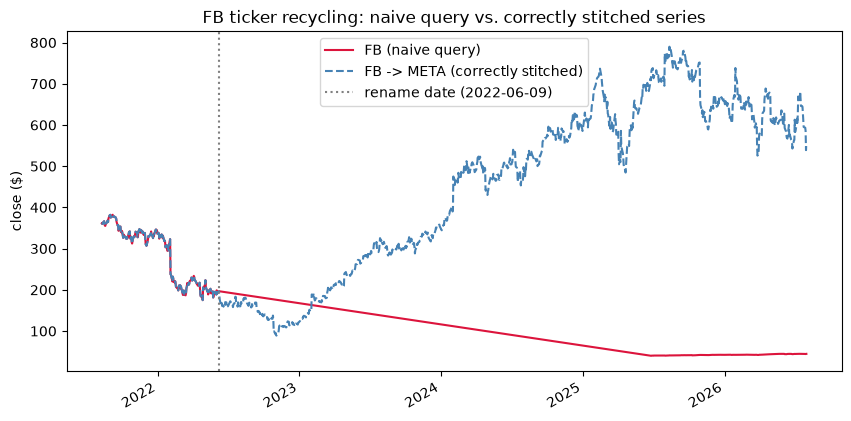

In [23]:
from datetime import date

import matplotlib.pyplot as plt

RENAME_DATE = date(2022, 6, 9)

# Naive: one query straight through the rename -- this is the trap.
fb_naive = (
    client.get_aggregate_bars(
        tickers=["FB"],
        multiplier=1,
        timespan="day",
        from_="2021-01-01",
        to="2026-08-01",
    )
    .collect()
    .with_columns(pl.col("timestamp").dt.date().alias("date"))
)

# Correct: bound each leg to the company that actually held the
# symbol on those dates, then concatenate.
fb_pre = client.get_aggregate_bars(
    tickers=["FB"],
    multiplier=1,
    timespan="day",
    from_="2021-01-01",
    to="2022-06-08",
).collect()
meta_post = client.get_aggregate_bars(
    tickers=["META"],
    multiplier=1,
    timespan="day",
    from_="2022-06-09",
    to="2026-08-01",
).collect()
composite = pl.concat([fb_pre, meta_post]).with_columns(
    pl.col("timestamp").dt.date().alias("date")
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fb_naive["date"], fb_naive["close"], color="crimson", label="FB (naive query)")
ax.plot(
    composite["date"],
    composite["close"],
    color="steelblue",
    linestyle="--",
    label="FB -> META (correctly stitched)",
)
ax.axvline(RENAME_DATE, color="gray", linestyle=":", label="rename date (2022-06-09)")
ax.set_ylabel("close ($)")
ax.set_title("FB ticker recycling: naive query vs. correctly stitched series")
ax.legend()
fig.autofmt_xdate()
plt.show()

## Rate-limiting across many tickers

Since each ticker is a separate API call, fetching a large watchlist can hit your plan's requests-per-second cap. Pass a `RateLimiter` to throttle calls automatically.

In [11]:
from xpectral.utils.rate_limiter import RateLimiter

limited_client = MassiveREST(rate_limiter=RateLimiter(calls=5, per_seconds=1))

limited_client.get_aggregate_bars(
    tickers=TICKERS,
    multiplier=1,
    timespan="day",
    from_="2024-12-01",
    to="2024-12-31",
).collect().shape

(105, 10)